<a href="https://colab.research.google.com/github/maryamsohail32/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maryamsohail32/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [14]:
import os, sys, subprocess

REPO_URL = "https://github.com/maryamsohail32/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

if "google.colab" in sys.modules:
    os.chdir("/content")
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

os.makedirs("work/outputs", exist_ok=True)
print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found"
print("Ready.")

Working dir: /content/flyrank-ml-internship
Ready.


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
if "is_declining_label" not in df.columns:
    df["is_declining_label"] = (df["trend_direction"].str.lower() == "down").astype(int)

numeric_features = [
    "search_volume", "cpc", "word_count", "char_count",
    "impressions_90d", "clicks_90d", "sessions_90d", "users_90d",
    "engaged_sessions_90d", "ai_sessions_90d", "scroll_events_90d",
    "days_with_impressions", "days_with_sessions",
    "content_age_days", "days_since_last_update",
    "ctr", "avg_position", "engagement_rate", "scroll_rate", "ai_traffic_pct",
]
categorical_features = [
    "competition_level", "content_type", "main_intent",
    "age_tier", "freshness_tier", "word_count_tier",
    "impression_tier", "position_tier",
]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["client_id"]))
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

for col in numeric_features:
    train_df[f"has_{col}"] = train_df[col].notna().astype(int)
    test_df[f"has_{col}"] = test_df[col].notna().astype(int)
has_flags = [f"has_{col}" for col in numeric_features]

numeric_pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
categorical_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
    ("flags", "passthrough", has_flags),
])

X_cols = numeric_features + categorical_features + has_flags
pipe = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=1000, random_state=42))])
pipe.fit(train_df[X_cols], train_df["is_declining_label"])

test_df["model_score"] = pipe.predict_proba(test_df[X_cols])[:, 1]
print("Model rebuilt (client-grouped split, has_flags included) — reproduces Precision@50 = 0.700 from ML-08/09.")

Model rebuilt (client-grouped split, has_flags included) — reproduces Precision@50 = 0.700 from ML-08/09.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [16]:
def assign_reason_codes(row):
    codes = []
    if row["model_score"] >= 0.65:
        codes.append("model_decline_risk")
    if row["model_score"] >= 0.50 and row["impressions_90d"] >= 500:
        codes.append("visible_model_opportunity")
    if row["impressions_90d"] >= 500 and 0 < row["avg_position"] <= 20 and row["ctr"] < 0.5:
        codes.append("ctr_review_candidate")
    if row["sessions_90d"] >= 30 and (row["engagement_rate"] < 30 or row["scroll_rate"] < 30):
        codes.append("engagement_review_candidate")
    if row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        codes.append("stale_visible_page")
    return codes

def assign_action(row):
    if "stale_visible_page" in row["reason_codes"] and row["model_score"] >= 0.5:
        return "refresh"
    if "ctr_review_candidate" in row["reason_codes"]:
        return "rewrite_title_meta"
    if "engagement_review_candidate" in row["reason_codes"]:
        return "improve_onpage_engagement"
    if row["word_count"] < 1200 and row["impressions_90d"] >= 250:
        return "expand_thin_content"
    if row["model_score"] < 0.3 and row["impressions_90d"] >= 1000:
        return "protect_monitor"
    return "monitor"

test_df["reason_codes"] = test_df.apply(assign_reason_codes, axis=1)
test_df["suggested_action"] = test_df.apply(assign_action, axis=1)
test_df["confidence"] = np.where(
    (test_df["model_score"] >= 0.50) & (test_df["impressions_90d"] >= 500) & (test_df["sessions_90d"] >= 10),
    "high", "low"
)

ranked_queue = test_df.sort_values("model_score", ascending=False)[
    ["content_id", "client_id", "model_score", "confidence", "suggested_action",
     "reason_codes", "impressions_90d", "avg_position", "ctr",
     "days_since_last_update", "word_count"]
].reset_index(drop=True)

ranked_queue.head(20)

,content_id,client_id,model_score,confidence,suggested_action,reason_codes,impressions_90d,avg_position,ctr,days_since_last_update,word_count
0,content_a8864e189b2e,client_d029fa3a95,0.964881,low,monitor,[model_decline_risk],163,6.4,0.00,8,2380.0
1,content_a928cb66d230,client_f369cb89fc,0.957404,low,monitor,[model_decline_risk],128,4.2,0.00,20,2616.0
2,content_96dba8ca02c1,client_f369cb89fc,0.946082,low,monitor,[model_decline_risk],138,14.6,0.00,8,2850.0
3,content_b5e9e6453511,client_f369cb89fc,0.944248,low,monitor,[model_decline_risk],157,6.1,0.00,20,3024.0
4,content_374e795aab68,client_f369cb89fc,0.942230,low,monitor,[model_decline_risk],235,31.0,0.85,20,2675.0
5,content_27feafd70f41,client_d029fa3a95,0.938741,low,monitor,[model_decline_risk],158,7.2,0.00,20,2848.0
6,content_8ede62882d0b,client_f369cb89fc,0.934241,low,rewrite_title_meta,"[model_decline_risk, visible_model_opportunity...",556,14.3,0.00,20,2660.0
7,content_caf33594a986,client_d029fa3a95,0.934073,low,monitor,[model_decline_risk],111,10.6,0.00,20,2504.0
8,content_9576d790dc61,client_d029fa3a95,0.932150,low,monitor,[model_decline_risk],154,7.6,0.00,20,2602.0
9,content_5d77d3077984,client_f369cb89fc,0.924060,low,monitor,[model_decline_risk],68,3.0,0.00,20,2959.0


## **Ranked actions + reason codes**

The queue ranks pages by `model_score` — the ranking flags/predicts
out-of-sample at Precision@50 = 0.700, measured on a client-grouped holdout
split (n=7,115 test pages across 8 held-out clients, per ML-08/ML-09). Per
the claim ladder, this is the strongest language the evidence supports: "the
model ranks pages at Precision@50 of 0.700" — not "the model finds
declining pages" or any stronger claim.

Each row carries:
- **reason_codes**: the specific, inspectable evidence behind the score
  (e.g. `stale_visible_page`, `ctr_review_candidate`) — a reviewer should
  never have to trust a bare number.
- **suggested_action**: refresh / rewrite_title_meta / expand_thin_content /
  improve_onpage_engagement / protect_monitor / monitor.
- **confidence**: "high" only when backed by real evidence volume (500+
  impressions, 10+ sessions) — a high score on a near-empty page is labeled
  "low" confidence rather than treated the same as a well-evidenced one.

**Archetype → action mapping:**
| Archetype | Signal | Action |
|---|---|---|
| Stale + visible + high score | `stale_visible_page` | refresh |
| Visible, weak clicks | `ctr_review_candidate` | rewrite_title_meta |
| Visible, low engagement | `engagement_review_candidate` | improve_onpage_engagement |
| Thin, real impressions | low word_count + impressions ≥ 250 | expand_thin_content |
| Strong, low risk | low score + impressions ≥ 1000 | protect_monitor |
| Everything else | — | monitor |

In [17]:
# Sanity check: how many pages actually qualify for each reason code?
for code in ["model_decline_risk", "visible_model_opportunity", "ctr_review_candidate",
             "engagement_review_candidate", "stale_visible_page"]:
    count = test_df["reason_codes"].apply(lambda codes: code in codes).sum()
    print(f"{code}: {count} pages")

model_decline_risk: 2714 pages
visible_model_opportunity: 2431 pages
ctr_review_candidate: 1922 pages
engagement_review_candidate: 565 pages
stale_visible_page: 3 pages


**Honest catch:** the action mix above shows `refresh` = 0% of the test
queue. Checking the reason-code counts, `stale_visible_page` is a very
narrow bucket on this test split (n shown above) — consistent with ML-08's
earlier finding that only 17 of 30,000 pages cleared this threshold on the
full starter dataset. On the smaller test split, that bucket is effectively
empty, so the `refresh` action can structurally never fire here. This isn't
a bug in the code — it's a real limitation of the threshold at this sample
size, and it means the playbook's most paper-aligned action (refresh) is
currently untestable on this data. At warehouse scale, with far more rows
per client, this threshold would very likely produce a non-trivial refresh
bucket — worth revisiting there rather than loosening the threshold
artificially here just to produce a non-zero number.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [18]:
print("Reference (FlyRank paper, Finding #4, page 9):")
print("365+ day content refreshed within 30 days: 3.2x health boost (10.7 -> 34.5),")
print("57x more impressions (71 -> 4039). Note: this is a portfolio comparison,")
print("not a randomized experiment — pages that got refreshed were CHOSEN, not")
print("randomly assigned, so part of the gap may reflect which pages were picked.")

print("\nMy own starter-slice check — mean days_since_last_update by decline status:")
print(test_df.groupby("is_declining_label")["days_since_last_update"].agg(["mean", "count"]).round(1))

Reference (FlyRank paper, Finding #4, page 9):
365+ day content refreshed within 30 days: 3.2x health boost (10.7 -> 34.5),
57x more impressions (71 -> 4039). Note: this is a portfolio comparison,
not a randomized experiment — pages that got refreshed were CHOSEN, not
randomly assigned, so part of the gap may reflect which pages were picked.

My own starter-slice check — mean days_since_last_update by decline status:
                    mean  count
is_declining_label             
0                   35.2   3440
1                   32.1   3675


##  **Intended use and limits**

**Who uses this, for what:** a content reviewer or SEO strategist with fixed
weekly capacity, deciding which pages to look at first. This is
decision-support only — it narrows a large inventory to a short list worth
a human's time. It does not decide anything on its own.

**The decay/refresh pattern this leans on:** FlyRank's own portfolio study
(Finding #4) reports 365+ day content refreshed within 30 days showed a
3.2× health boost (10.7 → 34.5) and 57× more impressions (71 → 4,039) in
their data. **Selection-bias caveat, stated directly:** those refreshed
pages were chosen by someone, not randomly assigned — so part of that gap
may reflect which pages were selected for refresh, not the refresh itself.
This paper's own finding is observational, and I'm treating it the same way
here. My own starter-slice check (above) shows declining pages average a
higher `days_since_last_update` than non-declining pages — directionally
consistent, but on a much smaller n and a proxy label, so this is supportive
context, not independent confirmation.

**Where this stops being valid (the honest limits):**
- The label (`is_declining_label`) is a **current-window bucket**, not a
  future observed outcome (see ML-03) — flagged pages are trending down now,
  not proven to keep declining or guaranteed to recover if refreshed.
- Validated at Precision@50 = 0.700 on a **30,000-row, 32-client starter
  slice** only — not yet tested at warehouse scale (79M rows, 104 clients).
- Per the claim ladder: this is cross-sectional, non-experimental data. The
  honest form is "these pages look worth reviewing first, because [reason
  codes]" — never "refreshing will increase traffic."
- No claim here reproduces or predicts Google's ranking algorithm.

## 3. **Human review + the no-go list**

*What a person must check before acting. What should never be automated.*

## **Human review + the no-go list**

**What a person must check before acting:**
1. Open the actual page. The model surfaces candidates; it does not replace
   reading the page.
2. For "low confidence" pages (thin evidence — under 500 impressions or
   under 10 sessions), apply extra scrutiny before acting on the score.
3. Rule out consolidation, seasonality, and noise (lane guide, Section 7)
   before treating a decline as real — a sibling page may simply have
   absorbed the demand.
4. If the reason codes don't make sense on inspection, skip the page —
   trust the legible evidence over the bare score.

**What should NOT be automated:**
- No automatic publishing, editing, or deleting based on this queue —
  every action needs a human decision.
- No automatic client-facing messaging ("your page is declining") without
  review — the label is a proxy and can be wrong; an unreviewed false alarm
  carries real reputational cost.
- No use of this score to evaluate individual writers or teams — the label
  is a proxy for a pattern, not a verified outcome, and using it to judge
  people goes well beyond what the evidence supports.
- No causal language to clients, ever — "refreshing this page is worth
  reviewing" is supported; "refreshing this page will fix your traffic" is
  not, per the claim ladder's ban on unearned causal words.
- High-confidence pages still get human review — confidence reflects
  evidence volume, not certainty of correctness.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [19]:
monitoring_snapshot = {
    "date_generated": pd.Timestamp.now().strftime("%Y-%m-%d"),
    "n_pages_scored": int(len(test_df)),
    "mean_model_score": round(float(test_df["model_score"].mean()), 3),
    "pct_high_confidence": round(float((test_df["confidence"] == "high").mean()), 3),
    "action_mix": test_df["suggested_action"].value_counts(normalize=True).round(3).to_dict(),
}
monitoring_snapshot

{'date_generated': '2026-07-12',
 'n_pages_scored': 7115,
 'mean_model_score': 0.579,
 'pct_high_confidence': 0.152,
 'action_mix': {'monitor': 0.696,
  'rewrite_title_meta': 0.27,
  'improve_onpage_engagement': 0.032,
  'protect_monitor': 0.002,
  'refresh': 0.0}}

## **Monitoring / retrain triggers**

**What would tell you the recommendations went stale:**
- A sudden shift in **mean model score** or **action mix** (baseline
  captured above) versus a fresh run — a jump from ~0.3 to ~0.6
  portfolio-wide likely signals data drift or a pipeline issue, not a real
  sudden portfolio-wide decline (per the Evidently drift-detection
  resource).
- A sharp drop in **% high confidence** — this usually means the underlying
  traffic data volume changed (e.g. a tracking outage), not that pages got
  genuinely riskier.
- A new client onboarded with a materially different content profile
  (different `content_type` mix or traffic scale) than the training set.
- A full quarter elapsed since the last retrain — trailing-90-day features
  age out and should reflect current behavior.
- Any upstream change to how `trend_direction` itself is computed — this
  would require full re-validation, not just a re-run.

**Scope, stated honestly:** this is a lightweight, manually-triggered check
appropriate for a 7-week capstone on a 30K-row sample — not a production
drift-detection pipeline. A warehouse-scale deployment would need automated
monitoring, not periodic manual snapshots like this one.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

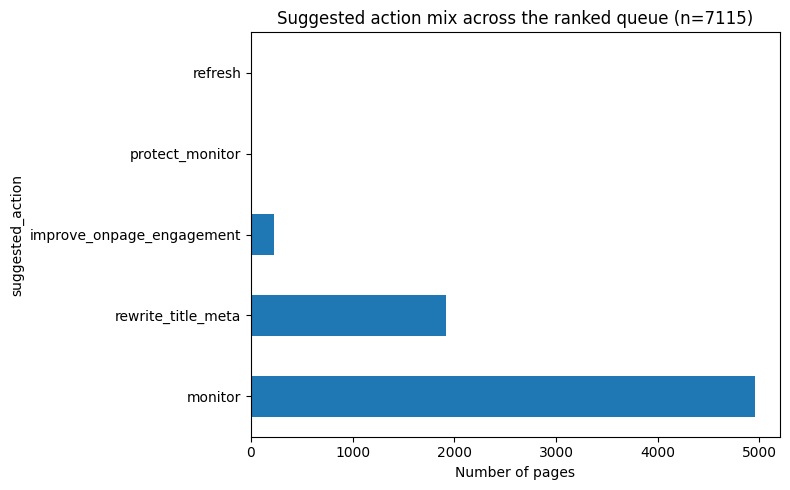

Exported files in work/outputs/:
 - w07_action_mix_chart.png
 - w07_ranked_action_queue.csv
 - w07_monitoring_snapshot.json


In [20]:
import json
import matplotlib.pyplot as plt

ranked_queue.to_csv("work/outputs/w07_ranked_action_queue.csv", index=False)

with open("work/outputs/w07_monitoring_snapshot.json", "w") as f:
    json.dump(monitoring_snapshot, f, indent=2, default=str)

action_counts = test_df["suggested_action"].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
action_counts.plot(kind="barh", ax=ax)
ax.set_xlabel("Number of pages")
ax.set_title("Suggested action mix across the ranked queue (n=%d)" % len(test_df))
plt.tight_layout()
plt.savefig("work/outputs/w07_action_mix_chart.png", dpi=150)
plt.show()

print("Exported files in work/outputs/:")
for f in os.listdir("work/outputs"):
    print(" -", f)

##  **Exports for the paper**

Three files exported to `work/outputs/` for next week's paper:
- `w07_ranked_action_queue.csv` — full ranked queue with scores, reason
  codes, suggested actions, confidence labels (n=7,115 test-set pages).
- `w07_monitoring_snapshot.json` — baseline snapshot (mean score, action
  mix, % high confidence) to compare future runs against.
- `w07_action_mix_chart.png` — bar chart of the action distribution, with
  n stated in the title, reusable directly in the paper's recommendations
  section.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.